## Warehouse Inventory Clustering Project

**Problem Statement**

A company manages a large number of inventory items in its warehouse. However, all items behave differently in terms of demand, stock movement, supplier reliability, and inventory risks. The objective of this project is to segment inventory items into meaningful groups using clustering techniques. This will help the company optimize stock levels, reduce stockouts, minimize holding costs, and improve supplier management decisions.

**Data Dictionary**

item_id – Unique identifier for each item

category – Product category

subcategory – Product subcategory

supplier_id – Supplier identifier

warehouse_zone – Storage location

avg_monthly_demand – Average demand per month

demand_variability – Variation in demand

avg_lead_time_days – Average supplier lead time

lead_time_variability – Variation in lead time

monthly_reorder_count – Number of reorders per month

stock_turnover_ratio – Inventory turnover rate

days_in_inventory – Days item stays in warehouse

stockout_frequency – Frequency of stockouts

backorder_frequency – Frequency of backorders

return_rate – Return percentage

damage_rate – Damage percentage

holding_cost_per_unit – Cost to hold one unit

unit_cost – Cost per unit

reorder_point_breaches – Times reorder level failed

supplier_delay_incidents – Supplier delay occurrences

current_stock – Current stock level

safety_stock – Safety stock maintained

excess_stock_level – Overstock quantity

inventory_value – Total value of inventory

warehouse_demand_pressure_index – Combined operational pressure metric

**Data Preprocessing**

Check for missing values and handle them appropriately. Remove duplicate records if present. Encode categorical variables such as category and warehouse zone. Scale numerical features using StandardScaler as clustering is distance-based. Outlier treatment should be carefully handled as some algorithms like DBSCAN use them as meaningful signals.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

In [3]:
df=pd.read_csv('warehouse_inventory_clustering_dataset.csv');

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   item_id                          4000 non-null   object 
 1   category                         4000 non-null   object 
 2   subcategory                      4000 non-null   object 
 3   supplier_id                      4000 non-null   object 
 4   warehouse_zone                   4000 non-null   object 
 5   avg_monthly_demand               4000 non-null   int64  
 6   demand_variability               4000 non-null   float64
 7   avg_lead_time_days               4000 non-null   float64
 8   lead_time_variability            4000 non-null   float64
 9   monthly_reorder_count            4000 non-null   int64  
 10  stock_turnover_ratio             4000 non-null   float64
 11  days_in_inventory                4000 non-null   int64  
 12  stockout_frequency  

In [5]:
df.shape

(4000, 25)

In [6]:
df.describe()

,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,stock_turnover_ratio,days_in_inventory,stockout_frequency,backorder_frequency,return_rate,damage_rate,holding_cost_per_unit,unit_cost,reorder_point_breaches,supplier_delay_incidents,current_stock,safety_stock,excess_stock_level,inventory_value,warehouse_demand_pressure_index
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4000.00000
mean,331.809250,0.285640,10.301275,0.258738,4.707250,5.944282,65.489750,2.491250,1.938000,0.028485,0.015713,47.709973,804.380267,2.657250,3.239750,317.102000,80.002750,104.915750,2.491254e+05,159.10009
std,228.438284,0.128173,5.592473,0.165963,2.991118,3.804082,56.855528,3.192487,2.503642,0.015560,0.008412,50.174326,741.472968,3.498976,3.615873,136.958627,55.192937,106.302228,2.508303e+05,88.27321
min,1.000000,0.080000,1.000000,0.050000,0.000000,0.200000,4.000000,0.000000,0.000000,0.005000,0.002000,0.520000,20.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000e+00,5.00000
25%,103.000000,0.190000,6.200000,0.130000,2.000000,2.140000,22.000000,0.000000,0.000000,0.017000,0.009000,12.565000,220.160000,0.000000,0.000000,219.000000,27.000000,32.000000,6.278350e+04,82.77000
50%,333.000000,0.260000,9.000000,0.200000,5.000000,6.150000,34.000000,1.000000,1.000000,0.026000,0.015000,33.710000,652.130000,1.000000,2.000000,304.000000,80.000000,60.000000,1.759532e+05,151.79500
75%,523.250000,0.370000,13.400000,0.360000,7.000000,9.140000,106.000000,4.000000,3.000000,0.037000,0.020000,64.495000,1108.817500,4.000000,5.000000,403.000000,122.000000,150.000000,3.498038e+05,228.21000
max,983.000000,0.620000,35.000000,0.720000,14.000000,15.890000,273.000000,15.000000,14.000000,0.080000,0.040000,502.570000,6085.330000,17.000000,18.000000,908.000000,306.000000,622.000000,2.093354e+06,300.00000


In [7]:
df.isnull().sum()

item_id                            0
category                           0
subcategory                        0
supplier_id                        0
warehouse_zone                     0
avg_monthly_demand                 0
demand_variability                 0
avg_lead_time_days                 0
lead_time_variability              0
monthly_reorder_count              0
stock_turnover_ratio               0
days_in_inventory                  0
stockout_frequency                 0
backorder_frequency                0
return_rate                        0
damage_rate                        0
holding_cost_per_unit              0
unit_cost                          0
reorder_point_breaches             0
supplier_delay_incidents           0
current_stock                      0
safety_stock                       0
excess_stock_level                 0
inventory_value                    0
warehouse_demand_pressure_index    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

In [13]:
df.columns

Index(['item_id', 'category', 'subcategory', 'supplier_id', 'warehouse_zone',
       'avg_monthly_demand', 'demand_variability', 'avg_lead_time_days',
       'lead_time_variability', 'monthly_reorder_count',
       'stock_turnover_ratio', 'days_in_inventory', 'stockout_frequency',
       'backorder_frequency', 'return_rate', 'damage_rate',
       'holding_cost_per_unit', 'unit_cost', 'reorder_point_breaches',
       'supplier_delay_incidents', 'current_stock', 'safety_stock',
       'excess_stock_level', 'inventory_value',
       'warehouse_demand_pressure_index'],
      dtype='object')

In [14]:
drop_columns=[
    'item_id',
    'supplier_id',
    'subcategory',
    'days_in_inventory',
    'unit_cost',
    'holding_cost_per_unit',
    'reorder_point_breaches',
    'safety_stock'
]

In [15]:
categorical_columns=[
    'category',
    'warehouse_zone'
]

In [17]:
selected_numerical_features=[
    'avg_monthly_demand',
    'demand_variability',
    'avg_lead_time_days',
    'lead_time_variability',
    'supplier_delay_incidents',
    'stock_turnover_ratio',
    'stockout_frequency',
    'backorder_frequency',
    'inventory_value',
    'current_stock',
    'excess_stock_level',
    'return_rate',
    'damage_rate',
    'warehouse_demand_pressure_index'
]

In [18]:
df_clean=df.drop(columns=drop_columns)

In [19]:
df_encoded=pd.get_dummies(df_clean,columns=categorical_columns,drop_first=True)

In [20]:
X=df_encoded

In [21]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [22]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   avg_monthly_demand               4000 non-null   int64  
 1   demand_variability               4000 non-null   float64
 2   avg_lead_time_days               4000 non-null   float64
 3   lead_time_variability            4000 non-null   float64
 4   monthly_reorder_count            4000 non-null   int64  
 5   stock_turnover_ratio             4000 non-null   float64
 6   stockout_frequency               4000 non-null   int64  
 7   backorder_frequency              4000 non-null   int64  
 8   return_rate                      4000 non-null   float64
 9   damage_rate                      4000 non-null   float64
 10  supplier_delay_incidents         4000 non-null   int64  
 11  current_stock                    4000 non-null   int64  
 12  excess_stock_level  

In [23]:
X_scaled.shape

(4000, 29)

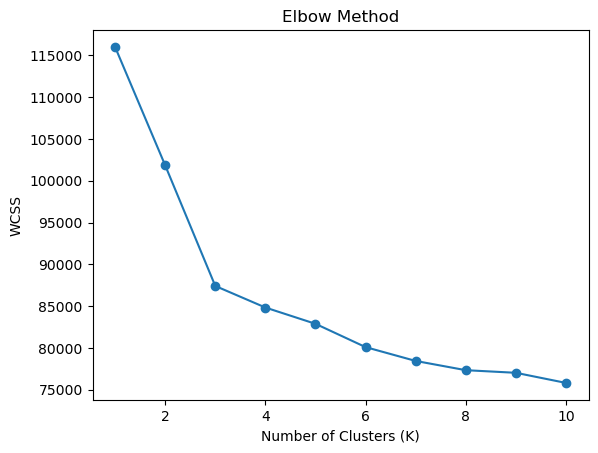

In [27]:
from sklearn.cluster import KMeans

wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [28]:
kmeans_3=KMeans(n_clusters=3,random_state=42)
df_encoded['Cluster_3']=kmeans_3.fit_predict(X_scaled)

kmeans_4=KMeans(n_clusters=4,random_state=42)
df_encoded['Cluster_4']=kmeans_4.fit_predict(X_scaled)

In [29]:
df_encoded.groupby('Cluster_3').mean()

,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,stock_turnover_ratio,stockout_frequency,backorder_frequency,return_rate,damage_rate,...,category_6,category_7,warehouse_zone_1,warehouse_zone_2,warehouse_zone_3,warehouse_zone_4,warehouse_zone_5,warehouse_zone_6,warehouse_zone_7,Cluster_4
Cluster_3,,,,,,,,,,,,,,,,,,,,,
0,80.417761,0.321537,9.712046,0.214193,1.530502,1.678077,0.688803,0.591506,0.034103,0.019467,...,0.119691,0.119691,0.136680,0.126641,0.115058,0.135907,0.118919,0.115830,0.12278,0.023166
1,525.839744,0.180513,6.045655,0.117215,6.488604,9.190506,0.722934,0.695157,0.022284,0.011046,...,0.135328,0.119658,0.126068,0.108262,0.110399,0.145299,0.128917,0.131054,0.12037,1.005698
2,372.649500,0.363359,15.480323,0.455803,5.946964,6.687586,6.193697,4.619523,0.029584,0.017012,...,0.118370,0.131437,0.118370,0.134512,0.129131,0.127594,0.128363,0.119908,0.12452,2.467333


In [30]:
df_encoded.groupby('Cluster_4').mean()

,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,stock_turnover_ratio,stockout_frequency,backorder_frequency,return_rate,damage_rate,...,category_6,category_7,warehouse_zone_1,warehouse_zone_2,warehouse_zone_3,warehouse_zone_4,warehouse_zone_5,warehouse_zone_6,warehouse_zone_7,Cluster_3
Cluster_4,,,,,,,,,,,,,,,,,,,,,
0,80.251362,0.321525,9.670817,0.213471,1.530739,1.675440,0.680934,0.585992,0.034105,0.019450,...,0.119066,0.119844,0.137743,0.126070,0.115953,0.136965,0.117510,0.115175,0.122957,0.000000
1,524.700714,0.179721,6.051143,0.116257,6.478571,9.176064,0.712857,0.683571,0.022296,0.011032,...,0.134286,0.120000,0.126429,0.108571,0.111429,0.144286,0.128571,0.130000,0.119286,1.002857
2,478.437229,0.393232,12.731025,0.421616,7.556999,8.479913,7.675325,5.708514,0.030045,0.016720,...,0.134199,0.122655,0.122655,0.122655,0.134199,0.150072,0.124098,0.118326,0.111111,1.988456
3,253.980707,0.330032,18.462862,0.491479,4.107717,4.664180,4.458199,3.353698,0.029066,0.017407,...,0.104502,0.139871,0.110932,0.147910,0.118971,0.102894,0.136656,0.125402,0.141479,1.967846


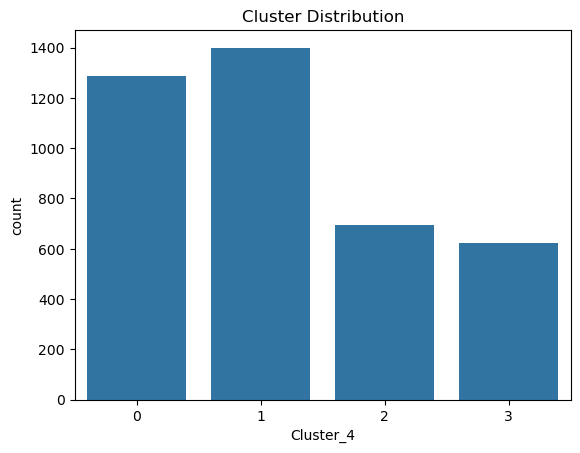

In [31]:
sns.countplot(x='Cluster_4',data=df_encoded)
plt.title("Cluster Distribution")
plt.show()

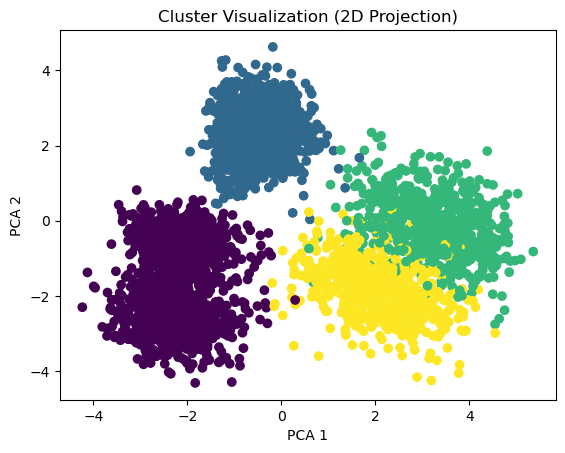

In [32]:
from sklearn.decomposition import PCA

pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:,0],X_pca[:,1],c=df_encoded['Cluster_4'])

plt.title('Cluster Visualization (2D Projection)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

In [33]:
from sklearn.cluster import DBSCAN

db=DBSCAN(eps=3.0,min_samples=5)
clusters=db.fit_predict(X)

In [34]:
df_encoded['DBSCAN_Cluster']=clusters

In [35]:
df_encoded['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
-1    4000
Name: count, dtype: int64

In [36]:
core_features=[
    'avg_monthly_demand',
    'demand_variability',
    'avg_lead_time_days',
    'stock_turnover_ratio',
    'stockout_frequency',
    'backorder_frequency',
    'inventory_value',
    'warehouse_demand_pressure_index'
]

In [37]:
X_core=df_encoded[core_features]

from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
X_scaled_core=scaler.fit_transform(X_core)

In [38]:
db=DBSCAN(eps=1.0,min_samples=10)
clusters=db.fit_predict(X_scaled_core)
df_encoded['DBSCAN_Cluster']=clusters

In [39]:
df_encoded['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
 0    3814
-1     186
Name: count, dtype: int64

In [40]:
outliers=df_encoded[df_encoded['DBSCAN_Cluster']==-1]

In [41]:
outliers.mean(numeric_only=True)

avg_monthly_demand                    473.370968
demand_variability                      0.384247
avg_lead_time_days                     14.196774
lead_time_variability                   0.410000
monthly_reorder_count                   6.166667
stock_turnover_ratio                    7.610591
stockout_frequency                      6.354839
backorder_frequency                     5.419355
return_rate                             0.028898
damage_rate                             0.016586
supplier_delay_incidents                6.752688
current_stock                         400.731183
excess_stock_level                     58.112903
inventory_value                    548134.425860
warehouse_demand_pressure_index       222.695538
category_1                              0.145161
category_2                              0.150538
category_3                              0.026882
category_4                              0.123656
category_5                              0.354839
category_6          

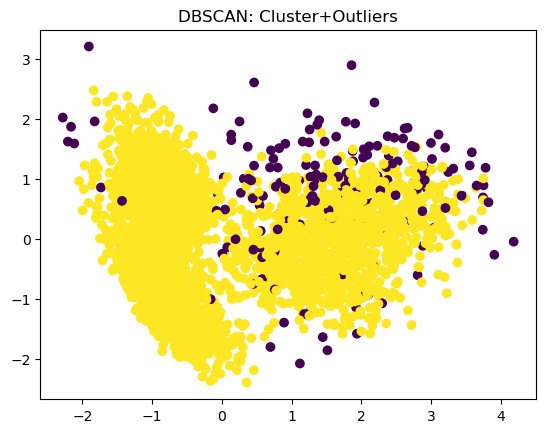

In [42]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled_core)
plt.figure()
plt.scatter(X_pca[:,0],X_pca[:,1],c=df_encoded['DBSCAN_Cluster'])
plt.title('DBSCAN: Cluster+Outliers')
plt.show()

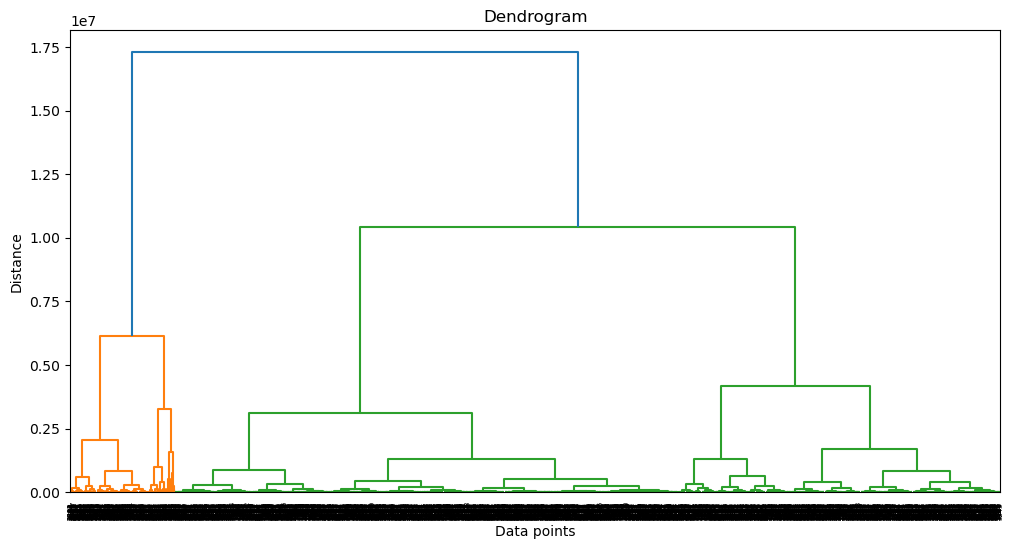

In [43]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked=linkage(X,method='ward')
plt.figure(figsize=(12,6))
dendrogram(linked)
plt.title('Dendrogram')
plt.xlabel('Data points')
plt.ylabel('Distance')
plt.show()

In [44]:
from sklearn.cluster import AgglomerativeClustering

hc=AgglomerativeClustering(n_clusters=4,linkage='ward')
clusters=hc.fit_predict(X)

In [46]:
df_encoded['HC_Cluster']=clusters

In [47]:
df_encoded['HC_Cluster'].value_counts()

HC_Cluster
2    2171
0    1381
3     337
1     111
Name: count, dtype: int64

In [50]:
df_encoded.groupby('HC_Cluster').mean(numeric_only=True)

,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,stock_turnover_ratio,stockout_frequency,backorder_frequency,return_rate,damage_rate,...,warehouse_zone_1,warehouse_zone_2,warehouse_zone_3,warehouse_zone_4,warehouse_zone_5,warehouse_zone_6,warehouse_zone_7,Cluster_3,Cluster_4,DBSCAN_Cluster
HC_Cluster,,,,,,,,,,,,,,,,,,,,,
0,359.507603,0.276307,9.839537,0.241224,4.805938,6.147495,2.233888,1.779870,0.027828,0.015185,...,0.128892,0.111513,0.116582,0.133961,0.126720,0.132513,0.128168,0.961622,1.078928,-0.046343
1,350.036036,0.247928,8.381081,0.188018,4.270270,5.311351,1.270270,1.153153,0.024261,0.013081,...,0.090090,0.171171,0.108108,0.135135,0.126126,0.171171,0.099099,0.540541,0.558559,-0.207207
2,301.921695,0.296564,10.907877,0.280129,4.648549,5.794169,2.798710,2.098572,0.029432,0.016342,...,0.130815,0.127130,0.116536,0.139567,0.124367,0.113772,0.116536,1.070014,1.285122,-0.016582
3,404.839763,0.265935,8.918101,0.215994,4.824926,6.287062,1.967359,1.810089,0.026463,0.014691,...,0.106825,0.124629,0.136499,0.127596,0.127596,0.121662,0.145401,0.875371,0.919881,-0.186944


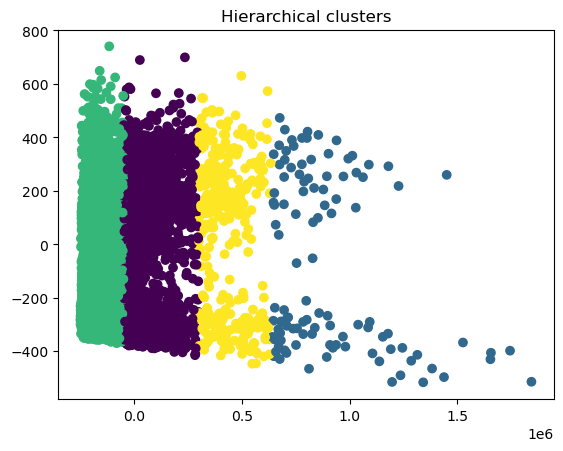

In [51]:
from sklearn.decomposition import PCA

pca=PCA(n_components=2)
X_pca=pca.fit_transform(X)
plt.figure()
plt.scatter(X_pca[:,0],X_pca[:,1],c=df_encoded['HC_Cluster'])
plt.title('Hierarchical clusters')
plt.show()

**Exploratory Data Analysis (EDA)**

-Perform Univariate Analysis to understand distribution of demand, cost, stock levels, and lead time.

-Perform Bivariate Analysis to study relationships such as demand vs stock, lead time vs stockouts, and cost vs inventory value. 

-Perform Multivariate Analysis to understand combined effects of multiple features on inventory behavior. Focus on extracting business insights such as fast-moving items, slow-moving items, stockout-prone items, and high-cost inventory segments.

In [52]:
features = [
    'avg_monthly_demand',
    'inventory_value',
    'current_stock',
    'avg_lead_time_days'
]

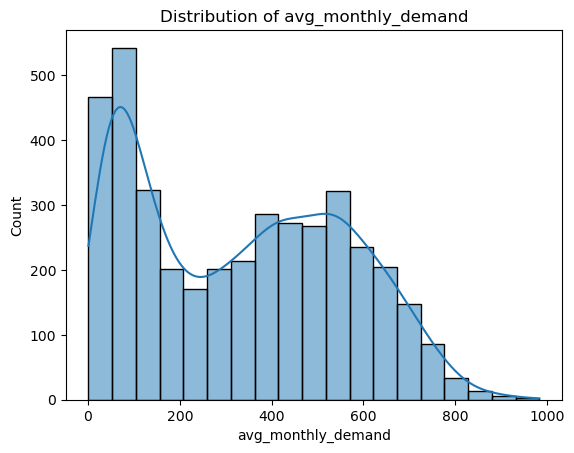

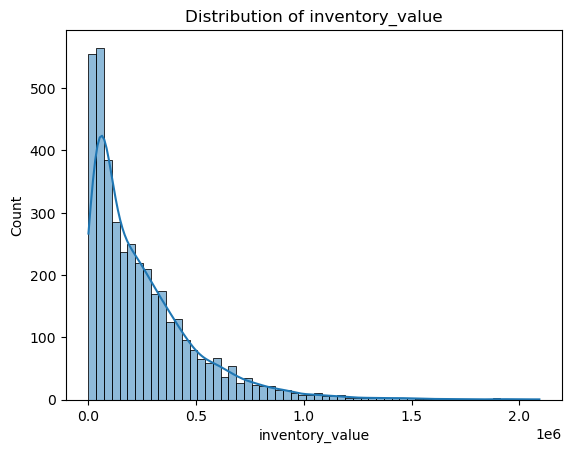

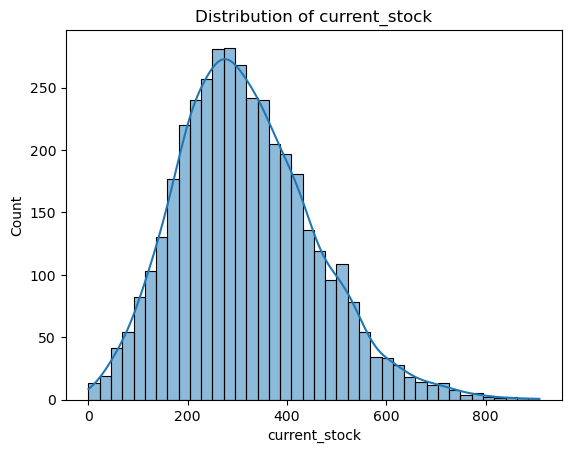

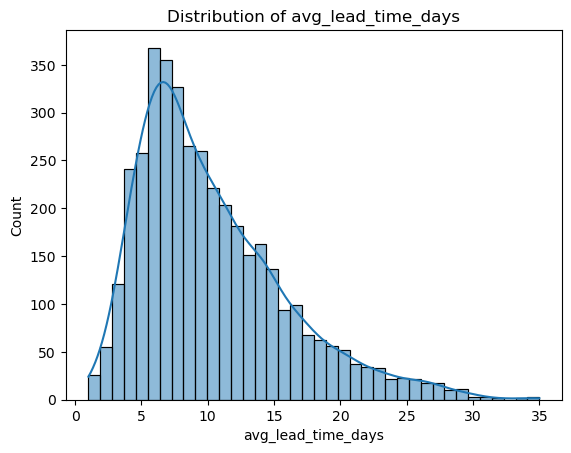

In [53]:
for col in features:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

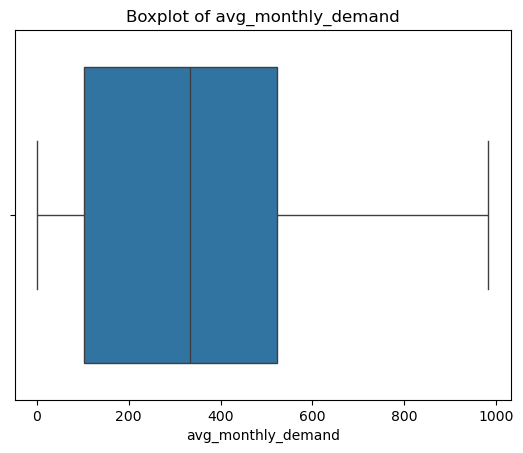

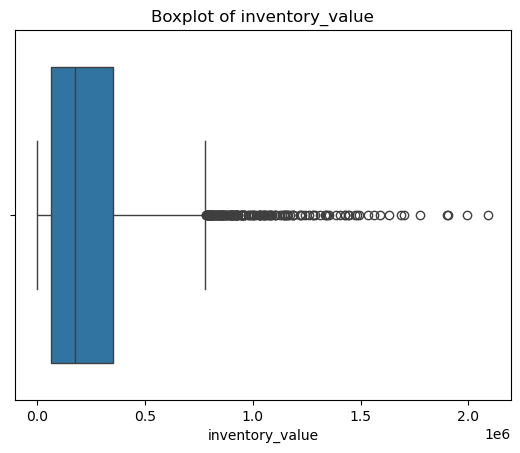

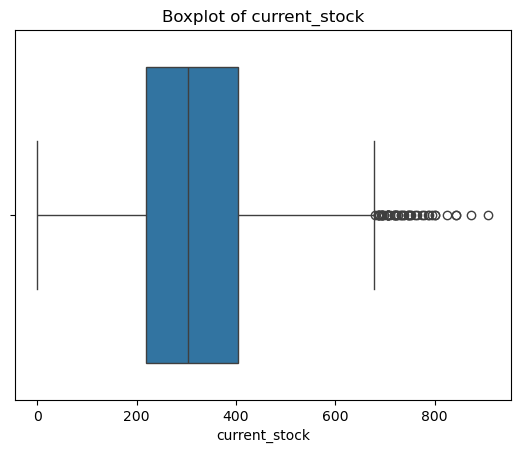

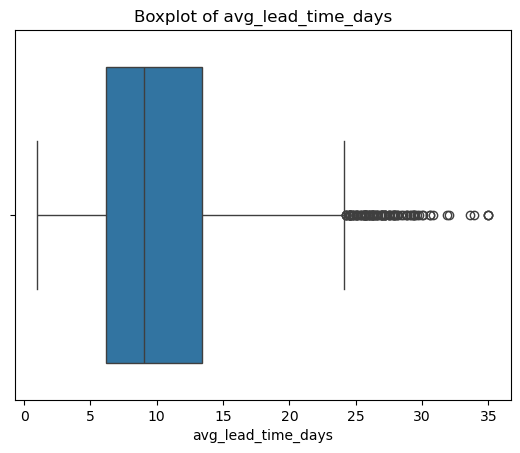

In [54]:
for col in features:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

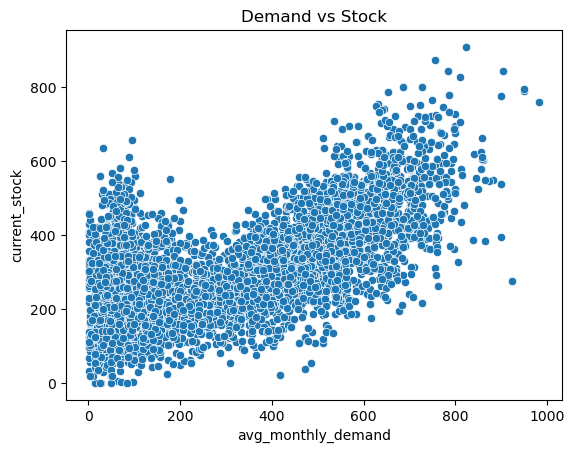

In [55]:
plt.figure()
sns.scatterplot(x='avg_monthly_demand', y='current_stock', data=df)
plt.title("Demand vs Stock")
plt.show()

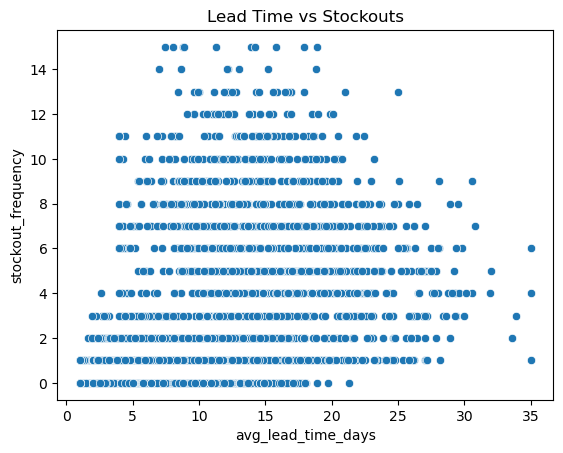

In [56]:
plt.figure()
sns.scatterplot(x='avg_lead_time_days', y='stockout_frequency', data=df)
plt.title("Lead Time vs Stockouts")
plt.show()

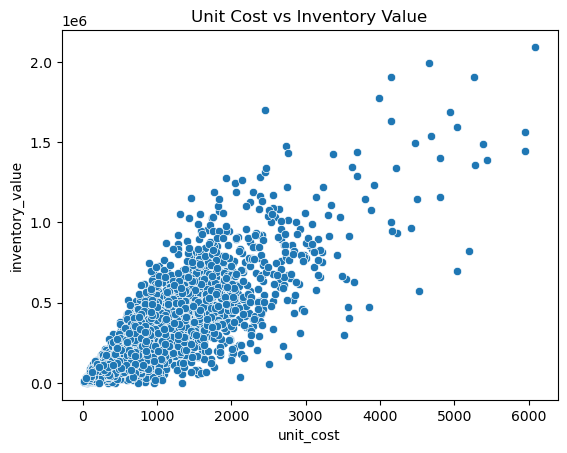

In [57]:
plt.figure()
sns.scatterplot(x='unit_cost', y='inventory_value', data=df)
plt.title("Unit Cost vs Inventory Value")
plt.show()

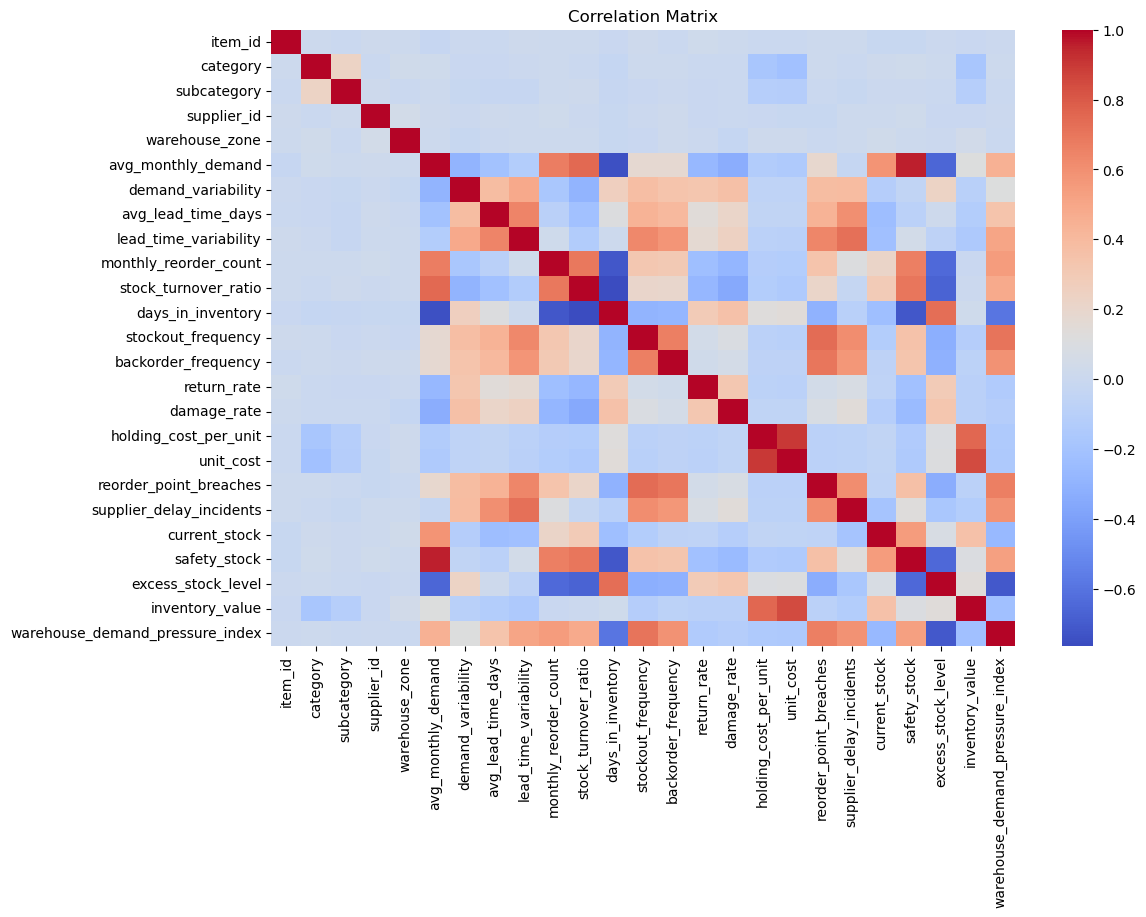

In [58]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

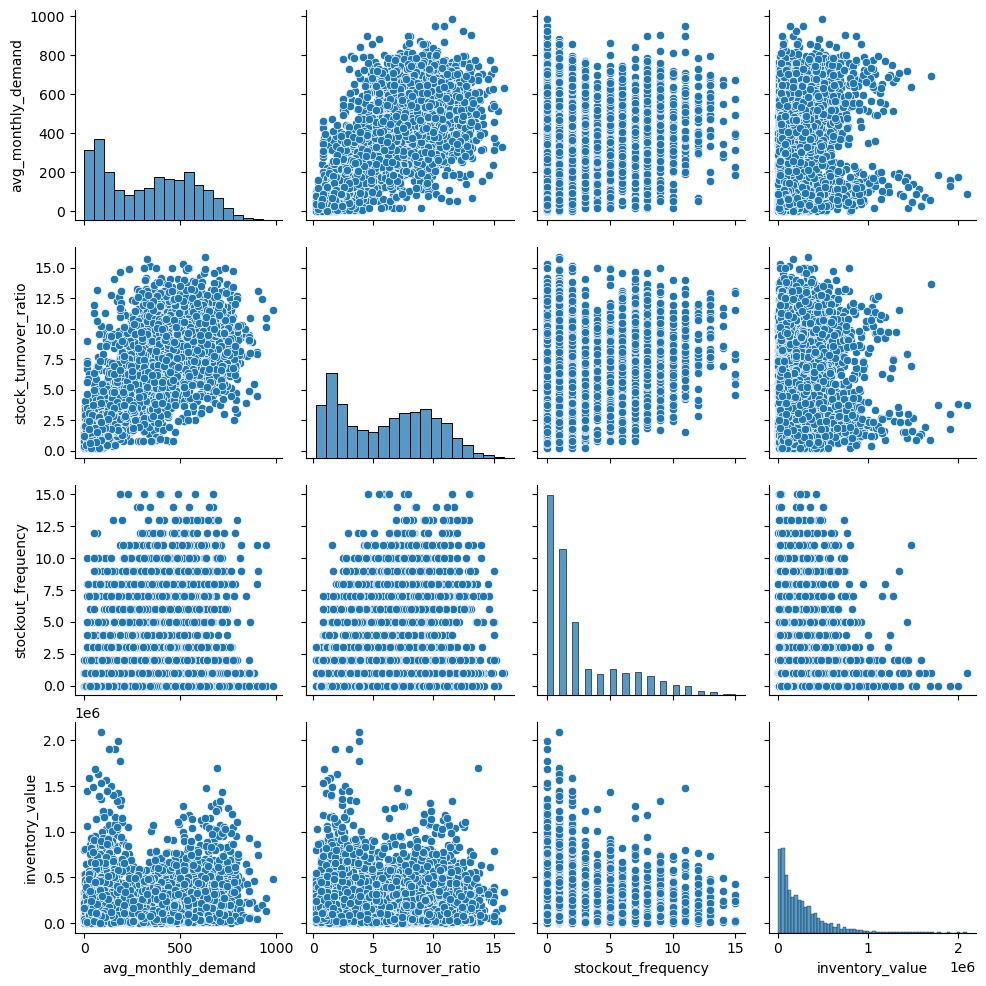

In [59]:
sns.pairplot(df[['avg_monthly_demand','stock_turnover_ratio','stockout_frequency','inventory_value']])
plt.show()